# Hydrostatic Column — manual troubleshooting bench (`iisph`)

The quiescent, wall-bounded, free-surface-under-gravity column
(`cases/hydrostaticColumn.py`). The exact solution is static: `v = 0`,
`p(y) = rho0 g (y_surf - y)`. The plan's **current best config** is
`--scheme iisph` (plain IISPH — one constant-density velocity-impulse
projection per step, no divergence-free pass, no VD+PS position shift) at the
default `nx = 128`. It *holds* — runs clean past `tLimit`, builds the exact
hydrostatic gradient (`pressureSlopeRatio` ~ 0.99), keeps the column body near
`rho0` — but it still **looks bad**, and this notebook is the bench for
chasing that:

- a **startup transient** (`t ~ 0.14 - 0.22`) where the raw hydrostatic IC
  seed relaxes onto the discretization — `embeddedMinDensity` dips to ~0.6,
  `pressureResidual` spikes;
- a **bounded, undamped free-slip bulk slosh** (Part 32's counter-rotating
  vortex pair) — `nu = 0`, the scheme family has no tangential stress, so
  nothing decays it; KE plateaus / slowly creeps;
- **cosmetic ballistic surface spray** — 1-3 fluid particles thrown 1-3 dx
  above the surface, reading `rho ~ 0.14 - 0.3` by kernel deficiency, which is
  all the plain `minDensity` FOM ever sees;
- particle-scale **pressure scatter** in the bulk (the Jacobi exits on a
  one-sided mean residual, not a tight per-particle one).

**The levers** are the `schemes/dfsphReference` module globals (`iisph_step`
routes through `dfsphReference_step`, so they all apply) plus the case's
`calibrateRestDensity` param. Every one has been A/B'd in
`DFSPH_IMPROVEMENT_PLAN.md` / `DFSPH_FINDINGS.md` Parts 23-34 — the toggle
cell below carries the one-line verdict for each. Flip one, re-run the
**IC + instrumentation + loop** cells, compare the trajectory panels.

Layout: knobs -> levers -> build IC -> look at the seed -> instrument the
solver -> the step loop (hook point exposed) -> encode video -> trajectory
panels -> final-state deep dive -> lever recipes.


In [1]:
%matplotlib widget
from warpSPHBootstrap import bootstrap
rt = bootstrap(precision='float32', verbose=True)

from warpSPH import *
from warpSPH.cases.hydrostaticColumn import hydrostaticColumnCase
from warpSPH.cases.plotting import Field, buildFieldPlotter, refreshFieldPlotter
from warpSPH.runner import CaseSpec, buildContext, encodeFrames
from warpSPH.io import prepExport
import warpSPH.schemes.dfsphReference as ref
from warpSPH.modules import computeDensities
from warpSPH.modules.util import countNeighbors

import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.autonotebook import tqdm

CASE = hydrostaticColumnCase

Warp 1.16.0 initialized:
   CUDA Toolkit 12.9, Driver 13.3
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 6000 Blackwell Workstation Edition" (95 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.16.0
{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}
Runtime(device=cuda:0, dtype=torch.float32, precision=float32, dim=typing.Any)


## Every knob, and what it does

The cell below is the command line of `hydrostaticColumn.py --scheme iisph`
written out. `CaseSpec` fields first, then `CASE.params` (each is also a
`--flag`). Anything not named keeps its value in `CASE.defaults` / `.params`.

| field | here | what it does |
|---|---|---|
| `nx` | `128` | particles across the box; `dx = L / nx`. Part 33 measured `iisph` at nx=32; Part 34 confirmed nx=128. |
| `L` | `1.0` | domain edge; the column fills the bottom `fillRatio` of it |
| `tLimit` | `1.0` | simulated-time limit **if** you run to time; the loop cell below uses an explicit `N_STEPS` instead |
| `cflFactor` | `0.4` | `dt <= 0.4 * dx / |v_max|` — Bender & Koschier's published constant (`kolmogorovIncompressibleTimestep`) |
| `dt` / `maxDt` | `1e-3` / `1e-2` | initial dt (quiescent start) and the ceiling the adaptive hook clamps to |
| `plotInterval` | `8` | steps between video frames |
| **`fillRatio`** | `0.5` | column depth as a fraction of `L`; hydrostatic drop is `rho0 g fillRatio L` |
| **`gravityMagnitude`** | `9.81` | `g`, pointing `-y` |
| **`jitter`** | `0.01` | lattice de-correlation of the fluid at `t=0` (dx units); the FOMs are taken from the jittered state |
| **`nu`** | `0.0` | physical viscosity. `0.0` is why the slosh never decays — raise it to test the free-slip diagnosis (Part 32) |
| **`calibrateRestDensity`** | `False` | normalise fluid mass so the at-rest bulk reads `rho0` (the `n_h=4` lattice integrates to ~0.95). Part 33: only speeds the gradient build under `iisph`, not needed; **detonates** with the DF solve in the loop |
| **`bulkMargin` / `wallMargin`** | `8` / `6` | skins (in dx) excluded from the pressure-vs-depth line fit |
| **`bandWidth`** | `16` | surface-detection bandwidth in dx (only used if `FREE_SURFACE_GAUGE` is on) |


In [27]:
spec = CaseSpec(caseName=CASE.name, scheme='iisph',
                params=dict(CASE.params)).merged(**CASE.defaults)

spec = spec.merged(
    # --- discretisation ----------------------------------------------------
    scheme='divergenceFree',
    nx=128,
    dim=2,
    L=1.0,

    # --- time stepping ---------------------------------------------------
    tLimit=1.0,
    cflFactor=0.4,
    dt=1e-3, maxDt=1e-2, minDt=1e-8,

    # --- output ----------------------------------------------------------
    caseName='07-hydrostaticColumn-troubleshoot',
    plot=True, show=False, plotInterval=8,
    store=False,

    # --- the column's own knobs ----------------------------------------------
    params=dict(
        fillRatio=0.5,
        gravityMagnitude=9.81,
        gravityDirection=[0.0, -1.0],
        jitter=0.0,
        nu=0.0,
        calibrateRestDensity=False,
        bulkMargin=8.0, wallMargin=6.0,
        bandWidth=16.0,
        markerSize=6,
    ),
    periodic=True
)
spec

CaseSpec(caseName='07-hydrostaticColumn-troubleshoot', nx=128, dim=2, L=1.0, n_h=4.0, periodic=True, scheme='divergenceFree', kernel='Wendland2', integrationScheme='semiImplicitEuler', supportMode='SuperSymmetric', gradientMode='Difference', laplacianMode='Brookshaw', samplingScheme='regular', verletScale=None, tLimit=1.0, dt=0.001, adaptiveDt=True, cflFactor=0.4, minDt=1e-08, maxDt=0.01, nSteps=None, precision='float32', device=None, plot=True, plotInterval=8, show=False, holdPlot=False, plotBackend=None, plotBackendOptions=None, store=False, storeMode='states', storeInterval=500, exportInterval=0.002, exportRoot=None, video=False, progress=None, verbose=False, quiet=False, params={'rho0': 1.0, 'targetDt': 0.0005, 'band': 0, 'freeSurface': False, 'inviscid': True, 'nu': 0.0, 'alpha': 0.01, 'markerSize': 6, 'fillRatio': 0.5, 'gravityMagnitude': 9.81, 'gravityDirection': [0.0, -1.0], 'bandWidth': 16.0, 'shifting': False, 'calibrateRestDensity': False, 'wallBC': 'freeSlip', 'jitter': 0.0

## Levers

`iisph_step` calls `dfsphReference_step(..., skipDivergence=True)`, so every
`ref.*` module global below is live. They all ship **off** on the registered
scheme; this cell is where you turn them on by hand. The verdicts are from
`DFSPH_FINDINGS.md` §2 / §9.

Flip one, then re-run **build IC -> instrument -> step loop -> panels**.


In [28]:
# --- dfsphReference module levers (Parts 26-33) --------------------------------
ref.SKIP_DIVERGENCE_SOLVE = True
#   True  = plain IISPH: one CD (constant-density) velocity-impulse solve. THE best config.
#   False = the two-solve DFSPH order (Part 29 linear divergence Jacobi at omega=0.3).
#           This is the instability source -- the inf-velocity / uniform-rho-0.139 soup
#           of Parts 29/30. Expect blow-ups on a woken-up free surface.

ref.DAMPED_WARM_START = False
#   Part 31: seed each solve with 0.5*min(carried, cap)/dt^k gated on the row being
#   compressed, instead of the full-kappa carry. Under the single solve it STARVES the
#   accumulating kappa -- pressureSlopeRatio stays ~0, the gradient never forms (Part 33).

ref.FREE_SURFACE_GAUGE = False
#   Part 30: hold kappa^v = 0 on detectFreeSurface-flagged rows in the DF solve.
#   Measured negative: no onset delay, deeper surface degradation, +30-40% slosh.
#   (Only does anything when SKIP_DIVERGENCE_SOLVE = False.)

ref.XSPH_FLUID_EPSILON = 0.0
#   Part 32: bulk XSPH velocity filter a_i -= (1/h) eps sum_j (m_j/rho_j)(v_i-v_j) W_ij.
#   Measured negative at eps_f=0.1: surface degrades earlier/deeper, 1/3 to the soup.

ref.XSPH_BOUNDARY_EPSILON = 0.0
#   Part 32: wall XSPH drag (boundary v = 0, so this is pure drag against the wall).
#   eps_b=0.1 was Part 32's n=1 lead ("first lever to hold the late-time surface") but
#   did NOT confirm at n=3 (Part 33). Does not decay the bulk slosh regardless.

print('levers:', dict(
    skipDivergence=ref.SKIP_DIVERGENCE_SOLVE,
    dampedWarmStart=ref.DAMPED_WARM_START,
    freeSurfaceGauge=ref.FREE_SURFACE_GAUGE,
    xsphFluid=ref.XSPH_FLUID_EPSILON,
    xsphBoundary=ref.XSPH_BOUNDARY_EPSILON,
))

levers: {'skipDivergence': True, 'dampedWarmStart': False, 'freeSurfaceGauge': False, 'xsphFluid': 0.0, 'xsphBoundary': 0.0}


## Build the initial condition

Explicit, through the real case code — `configureScheme` wires gravity /
viscosity / surface detection, `buildSystem` samples the column + the walls,
`initialConditions` jitters the fluid, optionally calibrates the rest density,
and seeds the **raw** analytic hydrostatic profile (`iisph` and
`dfsphReference` carry a non-negative pressure and warm-start their CD solve
from it directly; `divergenceFree` would get the zero-mean-shifted profile
instead).


In [29]:
ctx = buildContext(CASE, spec)
CASE.configureScheme(ctx)
system = CASE.buildSystem(ctx)
CASE.initialConditions(ctx, system)
runningState = system.initializeNewState()

kinds = system.state.kinds
fluid0 = (kinds == 0).cpu().numpy()
dxp = ctx.config.dx
g = ctx.param('gravityMagnitude')
rho0 = ctx.schemeConfig.fluid.restDensity
print(f'dt0 = {float(ctx.config.dt):.3e}   dx = {dxp:.4e}   rho0 = {rho0}   g = {g}')
print(f'{len(runningState.state.positions)} particles '
      f'({int((kinds == 0).sum())} fluid, {int((kinds != 0).sum())} boundary)')
print('surface-detection active:', ctx.schemeConfig.surfaceDetectionConfig.active,
      '  nu:', ctx.schemeConfig.diffusionParams.viscidNu)

dt0 = 1.000e-03   dx = 7.8125e-03   rho0 = 1.0   g = 9.81
13512 particles (8192 fluid, 5320 boundary)
surface-detection active: True   nu: 0.0


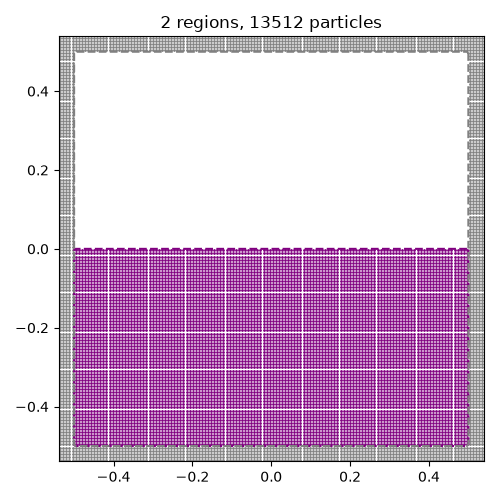

In [30]:
# Geometry sanity: the sampled regions (fluid + the container walls).
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
plotRegions(ctx.scratch['regions'], ax, plotFluid=True, plotParticles=True)
dom = ctx.config.domain
ax.set_aspect('equal')
ax.set_xlim(dom.min[0].item(), dom.max[0].item())
ax.set_ylim(dom.min[1].item(), dom.max[1].item())
ax.set_title(f"{len(ctx.scratch['regions'])} regions, "
             f"{len(runningState.state.positions)} particles")
fig.tight_layout()

### Is the seed actually hydrostatic?

Three views of `t = 0`, before a single step:

1. **fresh SPH density sum** `rho_i = sum_j m_j W_ij` on the seeded positions —
   a statement about the *sampling*. The `n_h = 4` Wendland lattice integrates
   to ~0.95 in the bulk (turn on `calibrateRestDensity` to lift it), and the
   flat free surface reads ~0.5 by truncation.
2. **pressure vs depth** with the analytic line `p = rho0 g (y_surf - y)` —
   the seed should sit exactly on it.
3. **per-particle rho histogram**, fluid vs boundary — where the spray will
   come from is already visible as the low-`rho` surface skin.


fluid rho sum: [0.6866, 1.0012], median 1.0012


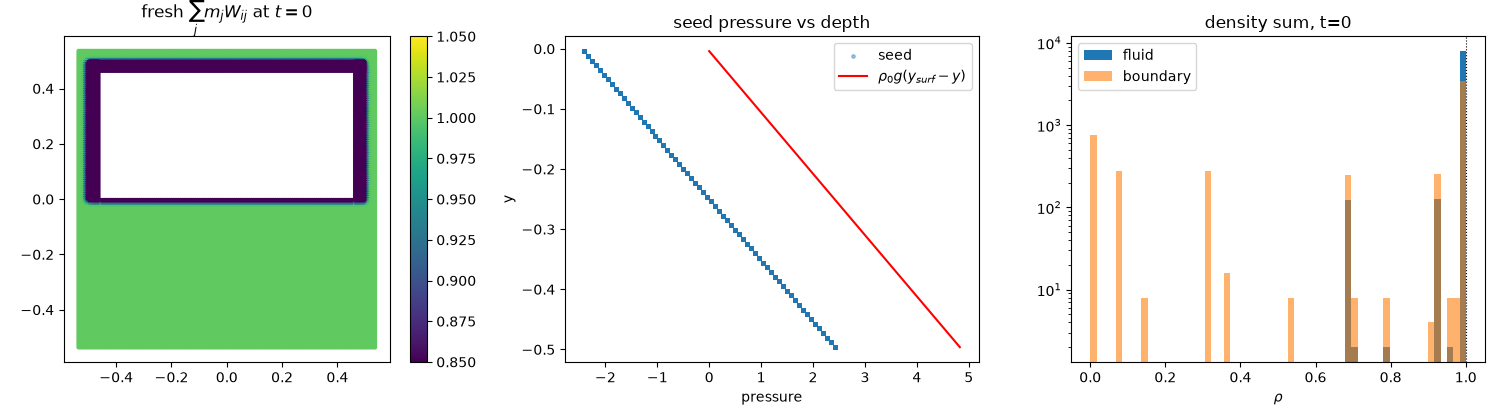

In [31]:
st = runningState.state
adj0 = ref._rebuildAdjacency(st, system, ctx.config)
rhoSum = computeDensities(st, ctx.config, ctx.schemeConfig, adj0).detach().cpu().numpy()
pos = st.positions.detach().cpu().numpy()
pres = st.pressures.detach().cpu().numpy()
ys = pos[fluid0, 1]
ysurf = ys.max()

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

sc = ax[0].scatter(pos[:, 0], pos[:, 1], c=rhoSum, s=6, cmap='viridis', vmin=0.85, vmax=1.05)
fig.colorbar(sc, ax=ax[0]); ax[0].set_aspect('equal')
ax[0].set_title(r'fresh $\sum_j m_j W_{ij}$ at $t=0$')

ax[1].scatter(pres[fluid0], ys, s=6, alpha=0.4, label='seed')
yy = np.linspace(ys.min(), ysurf, 50)
ax[1].plot(rho0 * g * (ysurf - yy), yy, 'r-', lw=1.5, label=r'$\rho_0 g (y_{surf}-y)$')
ax[1].set_xlabel('pressure'); ax[1].set_ylabel('y'); ax[1].legend()
ax[1].set_title('seed pressure vs depth')

lo, hi = rhoSum.min(), rhoSum.max()
bins = np.linspace(lo, hi, 60) if hi > lo else 1
ax[2].hist(rhoSum[fluid0], bins=bins, label='fluid')
ax[2].hist(rhoSum[~fluid0], bins=bins, alpha=0.6, label='boundary')
ax[2].axvline(rho0, color='k', ls=':', lw=0.8)
ax[2].set_xlabel(r'$\rho$'); ax[2].set_yscale('log'); ax[2].legend()
ax[2].set_title('density sum, t=0')
fig.tight_layout()

print(f'fluid rho sum: [{rhoSum[fluid0].min():.4f}, {rhoSum[fluid0].max():.4f}], '
      f'median {np.median(rhoSum[fluid0]):.4f}')

## Instrument the pressure solve

`ref._jacobiSolve` is the CD (and, with the divergence pass on, DF) Jacobi.
This cell wraps it to record, **per solve, per step**: iteration count, final
one-sided residual, full-field and wall-band (bottom 3 dx) pressure range,
`|a_p|max`. That is the readout Parts 25-29 were driven by — a solve that
exits clean on the mean while wall-adjacent `kappa` ratchets shows up here as
`nit` small but `pWall` range climbing step over step.

Re-run this cell whenever you re-run the build cell (it re-wraps the current
`ref._jacobiSolve`). Run the **restore** cell at the end to unwrap.


In [32]:
# solverLog = []          # one dict per (step, solve)
# _orig_js = ref._jacobiSolve
# _js_ctx = {'step': 0}

# def _recording_js(state, config, schemeConfig, adjacency, **kw):
#     a_p, p, nit, err = _orig_js(state, config, schemeConfig, adjacency, **kw)
#     fl = kw['fluidMask']
#     pos = state.positions
#     ylo = pos[fl, 1].min()
#     wall = fl & (pos[:, 1] < ylo + 3.0 * config.dx)

#     def rng(m):
#         return (float(p[m].min()), float(p[m].max())) if bool(m.any()) else (float('nan'),) * 2

#     pf = rng(fl); pw = rng(wall)
#     solverLog.append(dict(
#         step=_js_ctx['step'], mode=kw['mode'], nit=int(nit), err=float(err),
#         pFluidMin=pf[0], pFluidMax=pf[1], pWallMin=pw[0], pWallMax=pw[1],
#         apMax=float(a_p.norm(dim=-1).max()),
#         nSurfGauge=(int(kw['surfaceMask'].sum()) if kw.get('surfaceMask') is not None else 0),
#     ))
#     return a_p, p, nit, err

# ref._jacobiSolve = _recording_js
# print('wrapped ref._jacobiSolve; solverLog is recording')

## The step loop

The same call `warpSPH.runner._run` makes, unrolled. `N_STEPS` is the budget —
edit it. `iisph_step` integrates its own x / v / rho and hands the integrator
a no-op update, so `ctx.integrator.function` here just drives time and the
finalize copy. The hook point is marked; drop a perturbation or an extra probe
straight in.


In [36]:
N_STEPS = 800      # <-- the troubleshooting budget. ~t=1.0 is around step 440 at nx=128.

# export + live-panel setup (velocities / pressures / densities), via the
# generic hooks -- nothing re-derived.
ctx.exportPath = prepExport(spec.caseName, ctx.config, ctx.schemeConfig, ctx.scheme, ctx.exportFunction)
spec.save(os.path.join(ctx.exportPath, 'caseSpec.json'))
print('exporting frames to', ctx.exportPath)

from warpSPH.cases.plotting import Field, buildFieldPlotter, refreshFieldPlotter
FIELDS = [
    Field('velocities', 'velocities', colorMap='viridis', mapping='L2Norm'),
    Field('pressures', 'pressures', colorMap='RdBu', colorMapKind='diverging',
          flip=True, midPoint=0.0, vMin=-2.5, vMax=2.5),
    Field('densities', 'densities', colorMap='viridis', midPoint=1.0, vMin=0.85, vMax=1.05),
]
ctx.imagePath = os.path.join(ctx.exportPath, 'images')
os.makedirs(ctx.imagePath, exist_ok=True)

# _js_ctx['step'] = -1
# solverLog.clear()
# trajectory = [dict(CASE.diagnostics(ctx, runningState), step=-1, t=0.0)]


exporting frames to export/07-hydrostaticColumn-troubleshoot_2026-09-02_11-52-43


In [37]:
runningState = system.initializeNewState()
# refreshFieldPlotter(ctx, runningState, plotter, FIELDS, step=0)

In [38]:
system = runningState
from warpSPH.modules import *
from warpSPHCore import *
state = system.state
config = ctx.config


adjacency = buildVerletList(
    state, config.domain, verletScale=config.verletScale,
    supportMode=SupportScheme.SuperSymmetric,
    priorNeighborhood=system.adjacency, verbose=False)
system.adjacency = adjacency

state.densities = computeDensities(state, config, ctx.schemeConfig, adjacency)

In [39]:
from warpSPH.schemes.dfsphReference import _xspH

a_g = computeGravity(state, ctx.config, ctx.schemeConfig, adjacency)
a_g[state.kinds == 1] = 0.0
a_diff = computeVelocityDiffusion(state, ctx.config, ctx.schemeConfig, adjacency)

fluidMask = (state.kinds != 2)
a_xsph = _xspH(state, ctx.config, ctx.schemeConfig, adjacency, fluidMask)

Fluid Density min/max: 0.6866/1.0012


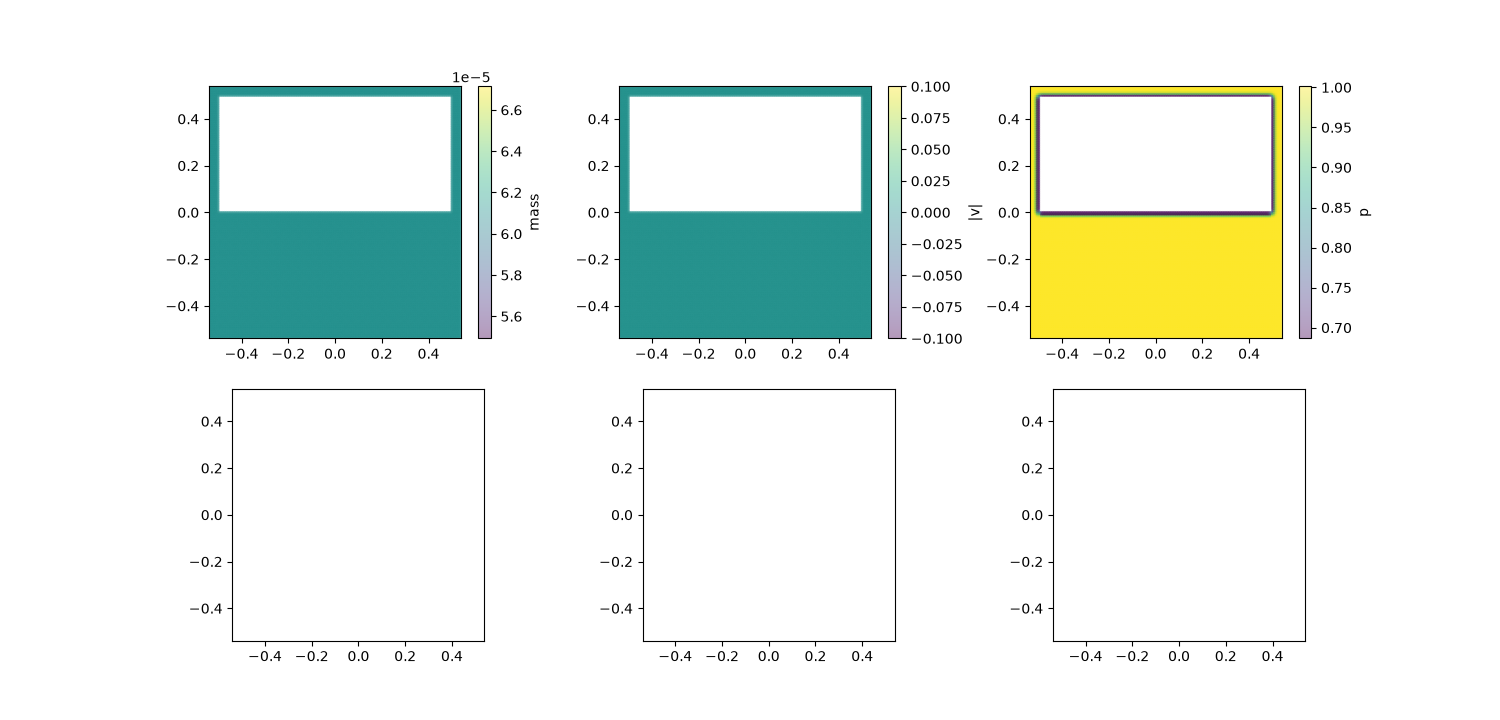

In [40]:
fig, axis = plt.subplots(2, 3, figsize=(15, 7.2), squeeze=False)
for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(ctx.config.domain.min[0].item(), ctx.config.domain.max[0].item())
    ax.set_ylim(ctx.config.domain.min[1].item(), ctx.config.domain.max[1].item())

pos = state.positions.detach().cpu().numpy()
plotMask = (state.kinds != 2).cpu().numpy()
sc = axis[0,0].scatter(pos[plotMask, 0], pos[plotMask, 1], s=6, c=state.masses.cpu().detach().numpy()[plotMask], alpha=0.4)
fig.colorbar(sc, ax=axis[0,0], label='mass')

sc = axis[0,1].scatter(pos[plotMask, 0], pos[plotMask, 1], s=6, c=state.velocities.norm(dim=-1).cpu().detach().numpy()[plotMask], alpha=0.4)
fig.colorbar(sc, ax=axis[0,1], label='|v|')

sc = axis[0,2].scatter(pos[plotMask, 0], pos[plotMask, 1], s=6, c=state.densities.cpu().detach().numpy()[plotMask], alpha=0.4)
fig.colorbar(sc, ax=axis[0,2], label='p')

print(f'Fluid Density min/max: {state.densities[fluidMask].min():.4f}/{state.densities[fluidMask].max():.4f}')

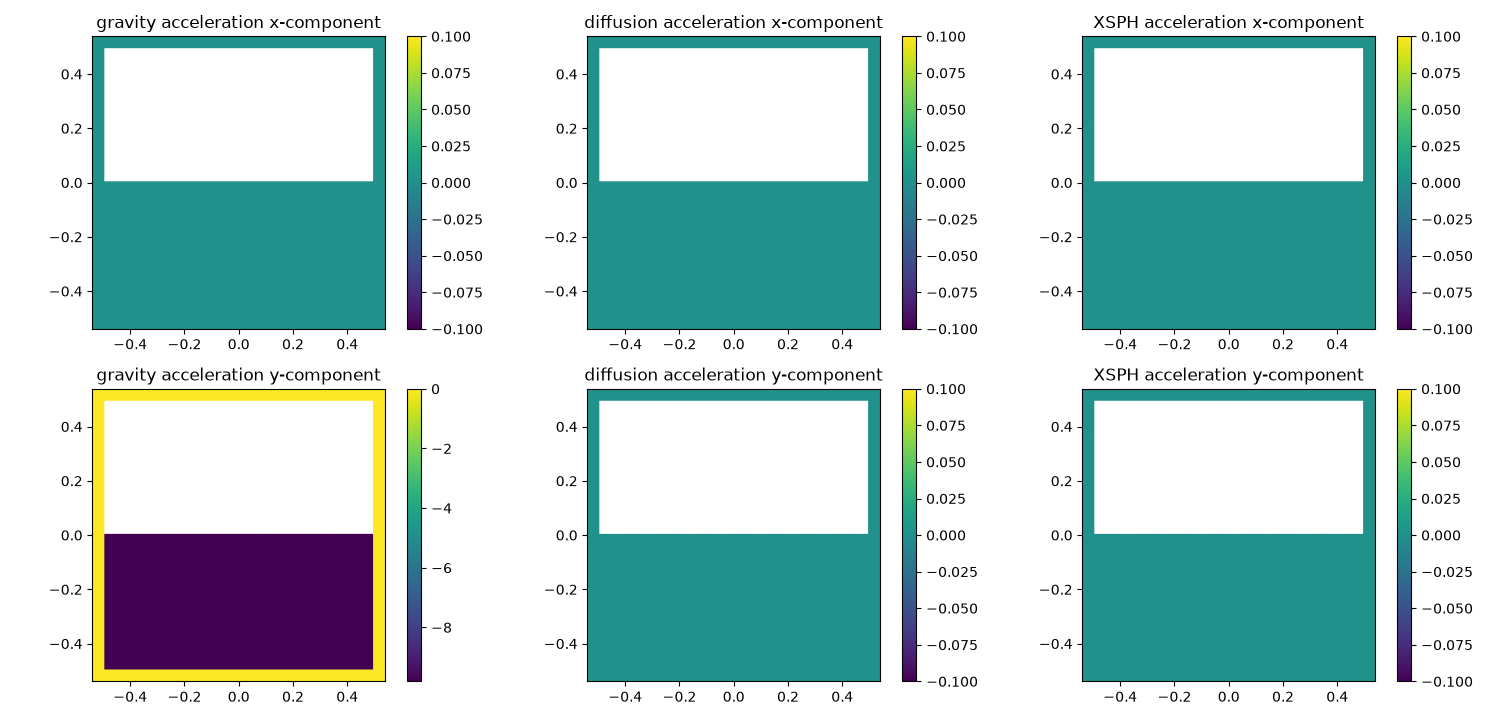

In [41]:
fig, axis = plt.subplots(2, 3, figsize=(15, 7.2), squeeze=False)
for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(ctx.config.domain.min[0].item(), ctx.config.domain.max[0].item())
    ax.set_ylim(ctx.config.domain.min[1].item(), ctx.config.domain.max[1].item())

pos = state.positions.detach().cpu().numpy()
plotMask = (state.kinds != 2).cpu().numpy()

sc = axis[0, 0].scatter(pos[plotMask, 0], pos[plotMask, 1], c=a_g[fluidMask, 0].detach().cpu().numpy(), s=6, cmap='viridis')
fig.colorbar(sc, ax=axis[0, 0]); axis[0, 0].set_title('gravity acceleration x-component')
sc = axis[1, 0].scatter(pos[plotMask, 0], pos[plotMask, 1], c=a_g[fluidMask, 1].detach().cpu().numpy(), s=6, cmap='viridis')
fig.colorbar(sc, ax=axis[1, 0]); axis[1, 0].set_title('gravity acceleration y-component')
sc = axis[0, 1].scatter(pos[plotMask, 0], pos[plotMask, 1], c=a_diff[fluidMask, 0].detach().cpu().numpy(), s=6, cmap='viridis')
fig.colorbar(sc, ax=axis[0, 1]); axis[0, 1].set_title('diffusion acceleration x-component')
sc = axis[1, 1].scatter(pos[plotMask, 0], pos[plotMask, 1], c=a_diff[fluidMask, 1].detach().cpu().numpy(), s=6, cmap='viridis')
fig.colorbar(sc, ax=axis[1, 1]); axis[1, 1].set_title('diffusion acceleration y-component')
sc = axis[0, 2].scatter(pos[plotMask, 0], pos[plotMask, 1], c=a_xsph[fluidMask, 0].detach().cpu().numpy(), s=6, cmap='viridis')
fig.colorbar(sc, ax=axis[0, 2]); axis[0, 2].set_title('XSPH acceleration x-component')
sc = axis[1, 2].scatter(pos[plotMask, 0], pos[plotMask, 1], c=a_xsph[fluidMask, 1].detach().cpu().numpy(), s=6, cmap='viridis')
fig.colorbar(sc, ax=axis[1, 2]); axis[1, 2].set_title('XSPH acceleration y-component')
fig.tight_layout()

In [42]:
# from typing import Optional
# def computePressureAccelIISPH(
#     state: CompressibleState,
#     pressureValues: torch.Tensor,
#     config: SimulationConfig,
#     supportScheme: SupportScheme = SupportScheme.Scatter,
#     adjacency: Optional[AdjacencyList] = None):
#     return -warpOperation(
#         state,
#         OperationProperties(
#             kernel = config.kernel,
#             operation = WarpOperation.Gradient,
#             gradientMode = GradientScheme.Symmetric,
#             supportMode = supportScheme,
#         ),
#         queryValues = pressureValues,
#         domain = config.domain,
#         adjacency=adjacency,
#     ) / state.densities[:, None]


# def _pressureAccel(state, config, adjacency, p, fluidMask):
#     a_p = computePressureAccelIISPH(
#         state=state, pressureValues=p, config=config,
#         supportScheme=SupportScheme.Scatter, adjacency=adjacency)
#     # Zero `a_p` for every non-fluid row `i` (`kind == 1` boundary AND `kind ==
#     # 2` ghost): a static particle takes no reaction (`staticBoundary` /
#     # `operatorMovesBoundary=False`), and ghosts are not real particles at all.
#     # `computePressureAccelIISPH` already excludes `kind == 2` *neighbours* from
#     # the sum (default `OperationDirection.AllToAll`), so this only touches the
#     # output rows.
#     return torch.where(fluidMask.unsqueeze(-1), a_p, torch.zeros_like(a_p))

# from typing import Any
# from warpSPH.schemes.dfsphReference import _drhodt, _factor


# def _idiotSolve(state: Any, config: Any, schemeConfig: Any, adjacency: Any, *,
#                  vEnter: torch.Tensor, rho0: float, warmStart: torch.Tensor,
#                  opDt: float, solverCfg: Any, minIters: int,
#                  fluidMask: torch.Tensor, mode: str,
#                  surfaceMask: torch.Tensor = None,
#                  warmStartDamped: bool = False):
#     fluidMask = state.kinds == 0
#     boundaryMask = state.kinds == 1
#     dt = config.dt

#     omega = 0.3
#     maxIters = solverCfg.maxIterations
#     tol = solverCfg.tolerance
#     alpha = -_factor(state, config, schemeConfig, adjacency) * config.dt**2
#     invDiag = 1.0 / (alpha)

#     drhodtEnter = _drhodt(state, config, schemeConfig, adjacency, vEnter)
#     source = 1.0 - state.densities / rho0 - dt * drhodtEnter / rho0

#     err = 0.0
#     it = 0
#     p = torch.zeros_like(state.pressures) 
#     for it in range(maxIters):
#         a_p = _pressureAccel(state, config, adjacency, p, state.kinds == 0)
#         ap = _drhodt(state, config, schemeConfig, adjacency, a_p) / rho0 * opDt
#         resid = source - ap
#         p = (p + omega * resid * invDiag).clamp(min=0.0)
#         # p = torch.where(fluidMask, p, torch.zeros_like(p))

#         print(f'it {it:3d}  err {err:.4e}  pFluid [{float(p[fluidMask].min()):.4e}, {float(p[fluidMask].max()):.4e}], pWall [{float(p[boundaryMask].min()):.4e}, {float(p[boundaryMask].max()):.4e}]')
#         if fluidMask.any():
#             residuum = torch.minimum(resid, torch.zeros_like(resid))
#             err = float(rho0 * (-residuum)[fluidMask].mean())
#         if it + 1 >= minIters and err < tol:
#             break

#     a_p = _pressureAccel(state, config, adjacency, p, state.kinds == 0)
#     return a_p, p, it + 1, err, source, alpha

In [43]:

# from warpSPH.schemes.dfsphReference import _jacobiSolve

# dt = ctx.config.dt
# solver = ctx.schemeConfig.solverConfig
# psCfg = solver.pressureSolver

# vEnter = st.velocities + dt * (a_g + a_diff + a_xsph)

# a_p_cd, kappa, nCd, errCd, source, alpha = _idiotSolve(
#     st, ctx.config, ctx.schemeConfig, adjacency, vEnter=vEnter, rho0=rho0,
#     warmStart=torch.zeros_like(st.pressures), opDt=dt * dt, solverCfg=psCfg,
#     minIters=32, fluidMask=st.kinds==0,
#     mode='density', warmStartDamped=False)

# print(f'CD solve: {nCd} iters, err={errCd:.3e}, p range [{kappa.min():.4f}, {kappa.max():.4f}]')

In [44]:
# fig, axis = plt.subplots(3, 3, figsize=(15, 10.2), squeeze=False)

# markerSize = 0.1
# drhodtEnter = _drhodt(state, ctx.config, ctx.schemeConfig, adjacency, vEnter)

# for ax in axis.flatten():
#     ax.set_aspect('equal')
#     ax.set_xlim(ctx.config.domain.min[0].item(), ctx.config.domain.max[0].item())
#     ax.set_ylim(ctx.config.domain.min[1].item(), ctx.config.domain.max[1].item())

# sc = axis[0, 0].scatter(st.positions[st.kinds == 0].cpu().detach().numpy()[:, 0], st.positions[st.kinds == 0].cpu().detach().numpy()[:, 1], c=source[st.kinds==0].detach().cpu().numpy(), s=markerSize, cmap='viridis')
# fig.colorbar(sc, ax=axis[0, 0]); axis[0, 0].set_title('source term (1 - rho/rho0 - dt drhodt/rho0)')
# sc = axis[1, 0].scatter(st.positions[st.kinds == 1].cpu().detach().numpy()[:, 0], st.positions[st.kinds == 1].cpu().detach().numpy()[:, 1], c=source[st.kinds==1].detach().cpu().numpy(), s=markerSize, cmap='viridis')
# fig.colorbar(sc, ax=axis[1, 0]); axis[1, 0].set_title('source term on wall (1 - rho/rho0 - dt drhodt/rho0)')
# sc = axis[2,0].scatter(st.positions[st.kinds != 2].cpu().detach().numpy()[:, 0], st.positions[st.kinds != 2].cpu().detach().numpy()[:, 1], c=source[st.kinds!=2].detach().cpu().numpy(), s=markerSize, cmap='viridis')
# fig.colorbar(sc, ax=axis[2, 0]); axis[2, 0].set_title('source term on both (1 - rho/rho0 - dt drhodt/rho0)')


# sc = axis[0, 1].scatter(st.positions[st.kinds == 0].cpu().detach().numpy()[:, 0], st.positions[st.kinds == 0].cpu().detach().numpy()[:, 1], c=drhodtEnter[st.kinds==0].detach().cpu().numpy(), s=markerSize, cmap='viridis')
# fig.colorbar(sc, ax=axis[0, 1]); axis[0, 1].set_title('drhodtEnter (from vEnter)')
# sc = axis[1,1].scatter(st.positions[st.kinds == 1].cpu().detach().numpy()[:, 0], st.positions[st.kinds == 1].cpu().detach().numpy()[:, 1], c=drhodtEnter[st.kinds==1].detach().cpu().numpy(), s=markerSize, cmap='viridis')
# fig.colorbar(sc, ax=axis[1, 1]); axis[1, 1].set_title('drhodtEnter (from vEnter) on wall')
# sc = axis[2,1].scatter(st.positions[st.kinds != 2].cpu().detach().numpy()[:, 0], st.positions[st.kinds != 2].cpu().detach().numpy()[:, 1], c=drhodtEnter[st.kinds!=2].detach().cpu().numpy(), s=markerSize, cmap='viridis')
# fig.colorbar(sc, ax=axis[2, 1]); axis[2, 1].set_title('drhodtEnter (from vEnter) on both')

# sc = axis[0, 2].scatter(st.positions[st.kinds == 0].cpu().detach().numpy()[:, 0], st.positions[st.kinds == 0].cpu().detach().numpy()[:, 1], c=alpha[st.kinds==0].detach().cpu().numpy(), s=markerSize, cmap='viridis')
# fig.colorbar(sc, ax=axis[0, 2]); axis[0, 2].set_title('alpha (diagonal) from CD solve')
# sc = axis[1, 2].scatter(st.positions[st.kinds == 1].cpu().detach().numpy()[:, 0], st.positions[st.kinds == 1].cpu().detach().numpy()[:, 1], c=alpha[st.kinds==1].detach().cpu().numpy(), s=markerSize, cmap='viridis')
# fig.colorbar(sc, ax=axis[1, 2]); axis[1, 2].set_title('alpha (diagonal) on wall from CD solve')
# sc = axis[2,2].scatter(st.positions[st.kinds != 2].cpu().detach().numpy()[:, 0], st.positions[st.kinds != 2].cpu().detach().numpy()[:, 1], c=alpha[st.kinds!=2].detach().cpu().numpy(), s=markerSize, cmap='viridis')
# fig.colorbar(sc, ax=axis[2, 2]); axis[2, 2].set_title('alpha (diagonal) on both from CD solve')

# fig.tight_layout()

In [45]:
# config.dt

In [46]:
# fig, axis = plt.subplots(2, 3, figsize=(15, 6.2), squeeze=False)

# for ax in axis.flatten():
#     ax.set_aspect('equal')
#     ax.set_xlim(ctx.config.domain.min[0].item(), ctx.config.domain.max[0].item())
#     ax.set_ylim(ctx.config.domain.min[1].item(), ctx.config.domain.max[1].item())




# sc = axis[0, 0].scatter(st.positions[st.kinds == 0].cpu().detach().numpy()[:, 0], st.positions[st.kinds == 0].cpu().detach().numpy()[:, 1], c=kappa[st.kinds==0].detach().cpu().numpy(), s=markerSize, cmap='RdBu')
# fig.colorbar(sc, ax=axis[0, 0]); axis[0, 0].set_title('pressure kappa after CD solve')
# sc = axis[0, 1].scatter(st.positions[st.kinds == 0].cpu().detach().numpy()[:, 0], st.positions[st.kinds == 0].cpu().detach().numpy()[:, 1], c=a_p_cd[st.kinds==0, 0].detach().cpu().numpy(), s=markerSize, cmap='viridis')
# fig.colorbar(sc, ax=axis[0, 1]); axis[0, 1].set_title('CD acceleration x-component')
# sc = axis[0, 2].scatter(st.positions[st.kinds == 0].cpu().detach().numpy()[:, 0], st.positions[st.kinds == 0].cpu().detach().numpy()[:, 1], c=a_p_cd[st.kinds==0, 1].detach().cpu().numpy(), s=markerSize, cmap='viridis')
# fig.colorbar(sc, ax=axis[0, 2]); axis[0, 2].set_title('CD acceleration y-component')

# sc = axis[1, 0].scatter(st.positions[st.kinds == 1].cpu().detach().numpy()[:, 0], st.positions[st.kinds == 1].cpu().detach().numpy()[:, 1], c=kappa[st.kinds==1].detach().cpu().numpy(), s=markerSize, cmap='RdBu')
# fig.colorbar(sc, ax=axis[1, 0]); axis[1, 0].set_title('pressure kappa after CD solve (boundary)')
# sc = axis[1, 1].scatter(st.positions[st.kinds == 1].cpu().detach().numpy()[:, 0], st.positions[st.kinds == 1].cpu().detach().numpy()[:, 1], c=a_p_cd[st.kinds==1, 0].detach().cpu().numpy(), s=markerSize, cmap='viridis')   
# fig.colorbar(sc, ax=axis[1, 1]); axis[1, 1].set_title('CD acceleration x-component (boundary)')
# sc = axis[1, 2].scatter(st.positions[st.kinds == 1].cpu().detach().numpy()[:, 0], st.positions[st.kinds == 1].cpu().detach().numpy()[:, 1], c=a_p_cd[st.kinds==1, 1].detach().cpu().numpy(), s=markerSize, cmap='viridis')
# fig.colorbar(sc, ax=axis[1, 2]); axis[1, 2].set_title('CD acceleration y-component (boundary)')


# fig.tight_layout()



In [54]:

runningState = system.initializeNewState()
plotter = buildFieldPlotter(ctx, runningState, FIELDS, figsize=(15, 5))

RFBOutputContext()

In [55]:

runningState = system.initializeNewState()
for i in (tq := tqdm(range(N_STEPS), leave=True)):
    # _js_ctx['step'] = i
    # ---- hook point ------------------------------------------------------
    stepResult = ctx.integrator.function(
        state=runningState, f=ctx.stepFunction, dt=1e-3,
        config=ctx.config, schemeConfig=ctx.schemeConfig, verbose=True,
    )
    runningState = stepResult.state
    if CASE.timestep is not None:
        ctx.config.dt = CASE.timestep(ctx, runningState)
    # --------------------------------------------------------------------

    t = runningState.t.item() if torch.is_tensor(runningState.t) else runningState.t
    row = CASE.diagnostics(ctx, runningState)
    # trajectory.append(dict(row, step=i, t=t))
    tq.set_description(
        f"t={t:.3f} dt={float(ctx.config.dt):.1e} |v|max={row['maxVelocity']:.2f} "
        f"slope={row.get('pressureSlopeRatio', float('nan')):.2f} "
        f"embMin={row.get('embeddedMinDensity', float('nan')):.2f} "
        f"minRho={row['minDensity']:.2f}")

    # if i % spec.plotInterval == 0 or i == N_STEPS - 1:
    refreshFieldPlotter(ctx, runningState, plotter, FIELDS, step=i)

    if not np.isfinite(row['maxVelocity']) or row['maxVelocity'] > 1e4:
        print(f'\n*** blow-up at step {i}, t={t:.4f} ***')
        break
    # break
# print('done:', len(trajectory) - 1, 'steps, final t =', trajectory[-1]['t'])

  0%|          | 0/800 [00:00<?, ?it/s]

[Initialize] Initializing at t=0.0000 with dt=0.0010 (default hook)
Initializing new state [t=0.0]
[Pre] Preprocessing at t=0.0000 with dt=0.0010 (default hook)
[Post] Postprocessing at t=0.0000 with dt=0.0010 (default hook)
Initializing new state [t=0.0]
[Finalize] Finalizing at t=0.0000 with dt=0.0010 (default hook)

*** blow-up at step 0, t=0.0010 ***


In [ ]:
mp4 = encodeFrames(ctx.imagePath, ctx.exportPath)
print('video:', mp4)

## Trajectory panels

- **geometry** — 95th-pct surface height and column base. Flat = the column
  holds; drift/collapse = the failure the case exists to expose.
- **kinetic energy** — the bounded free-slip slosh. Plateau or slow creep is
  "as good as it gets" without a real viscosity; a knee upward is a blow-up.
- **density FOMs** — `minDensity` (the plain one, = spray) vs `densityP05` and
  `embeddedMinDensity` (spray-robust, = the column body). The gap between them
  *is* the spray artifact.
- **hydrostatic gradient** — `pressureSlopeRatio` (target `1.0`) and
  `pressureResidual` (spurious non-linearity, normalised by `rho0 g H`).
- **solver** — CD / DF iteration counts and residuals per step, from
  `solverLog`. Ratcheting wall pressure or a residual that never falls is the
  tell.


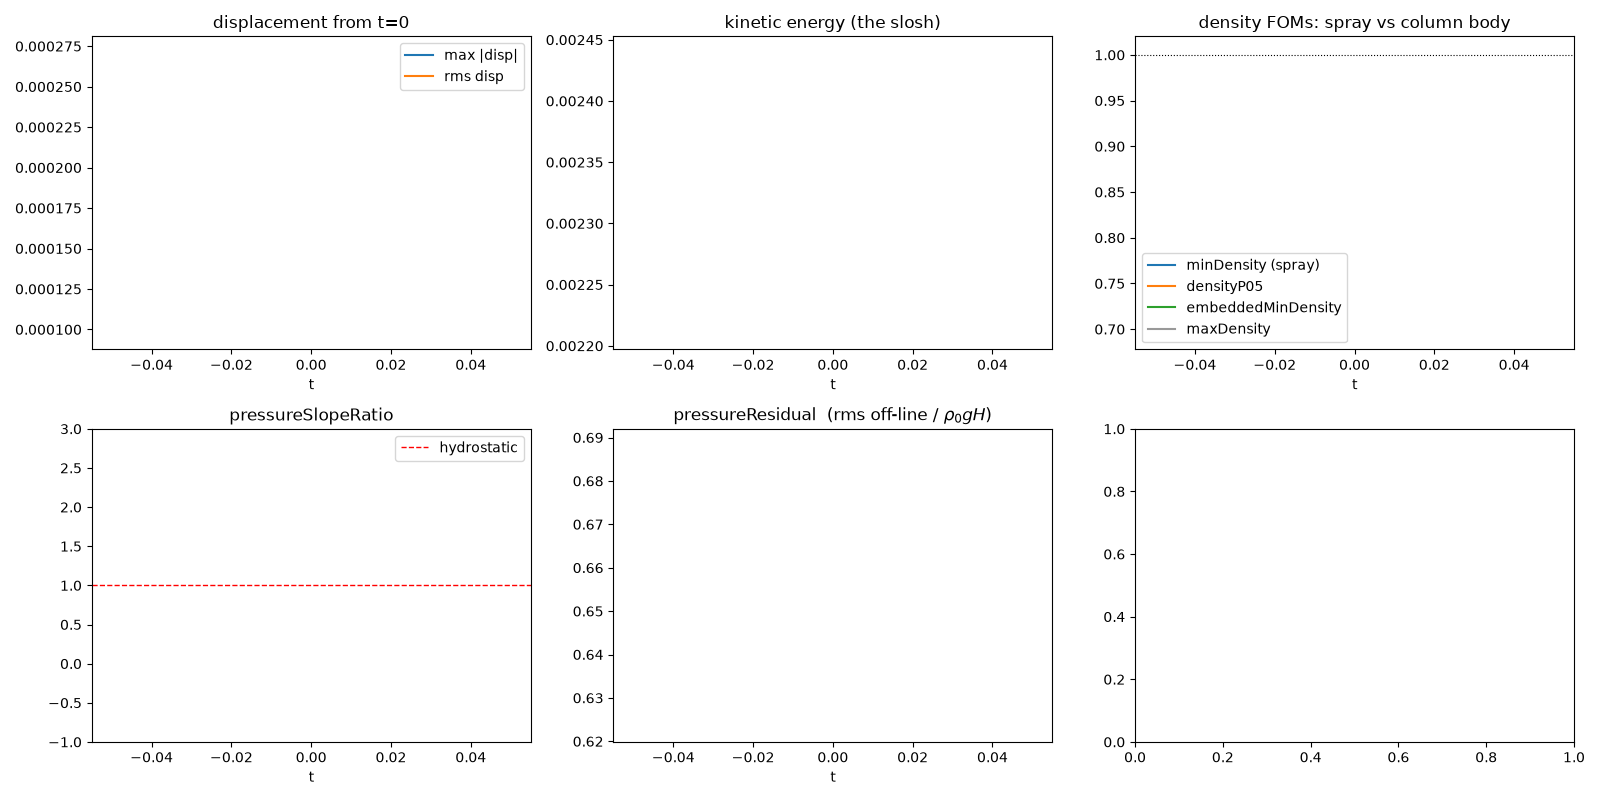

In [ ]:
def series(key):
    return np.array([r.get(key, np.nan) for r in trajectory], float)

t = series('t')
fig, ax = plt.subplots(2, 3, figsize=(16, 8))

ax[0, 0].plot(t, series('dispMax'), label='max |disp|')
ax[0, 0].plot(t, series('dispRms'), label='rms disp')
ax[0, 0].set_title('displacement from t=0'); ax[0, 0].set_xlabel('t'); ax[0, 0].legend()

ax[0, 1].plot(t, series('kineticEnergy'))
ax[0, 1].set_title('kinetic energy (the slosh)'); ax[0, 1].set_xlabel('t')

ax[0, 2].plot(t, series('minDensity'), label='minDensity (spray)')
ax[0, 2].plot(t, series('densityP05'), label='densityP05')
ax[0, 2].plot(t, series('embeddedMinDensity'), label='embeddedMinDensity')
ax[0, 2].plot(t, series('maxDensity'), label='maxDensity', color='0.6')
ax[0, 2].axhline(1.0, color='k', ls=':', lw=0.8)
ax[0, 2].set_title('density FOMs: spray vs column body'); ax[0, 2].set_xlabel('t'); ax[0, 2].legend()

ax[1, 0].plot(t, series('pressureSlopeRatio'))
ax[1, 0].axhline(1.0, color='r', ls='--', lw=1, label='hydrostatic')
ax[1, 0].set_ylim(-1, 3); ax[1, 0].set_title('pressureSlopeRatio'); ax[1, 0].set_xlabel('t'); ax[1, 0].legend()

ax[1, 1].plot(t, series('pressureResidual'))
ax[1, 1].set_title(r'pressureResidual  (rms off-line / $\rho_0 g H$)'); ax[1, 1].set_xlabel('t')

cd = [r for r in solverLog if r['mode'] != 'divergence']
df = [r for r in solverLog if r['mode'] == 'divergence']
if cd:
    cs, cn = np.array([r['step'] for r in cd]), np.array([r['nit'] for r in cd])
    ce, cw = np.array([r['err'] for r in cd]), np.array([r['pWallMax'] for r in cd])
    axb = ax[1, 2]
    axb.plot(cs, cn, '.', ms=3, label='CD iters')
    if df:
        ds, dn = np.array([r['step'] for r in df]), np.array([r['nit'] for r in df])
        axb.plot(ds, dn, '.', ms=3, label='DF iters')
    axb.set_xlabel('step'); axb.set_ylabel('iterations'); axb.legend(loc='upper left')
    axt = axb.twinx()
    axt.plot(cs, cw, 'r-', lw=0.7, alpha=0.7, label='CD pWallMax')
    axt.set_ylabel('CD wall-band $p_{max}$', color='r')
    axb.set_title('solver: iterations & wall pressure')
fig.tight_layout()

## Final-state deep dive

Where the "horrendous" lives, on the last recorded state:

- **pressure vs depth** with the analytic line and the bulk least-squares fit
  (the same fit the `pressureSlopeRatio` FOM uses) — the scatter around the
  line is `pressureResidual`.
- **speed field** — the vortex pair / wall jets. Free-slip: the flow slides
  down the walls, turns along the floor, and rolls up.
- **neighbour count** — the spray is the handful of fluid particles with far
  fewer neighbours than the ~50 a bulk particle keeps; those are exactly the
  low-`rho` readings the plain `minDensity` reports.


neighbour median (fluid): 45   spray-like (< 0.5x median neighbours): 0 particles   (none this frame)


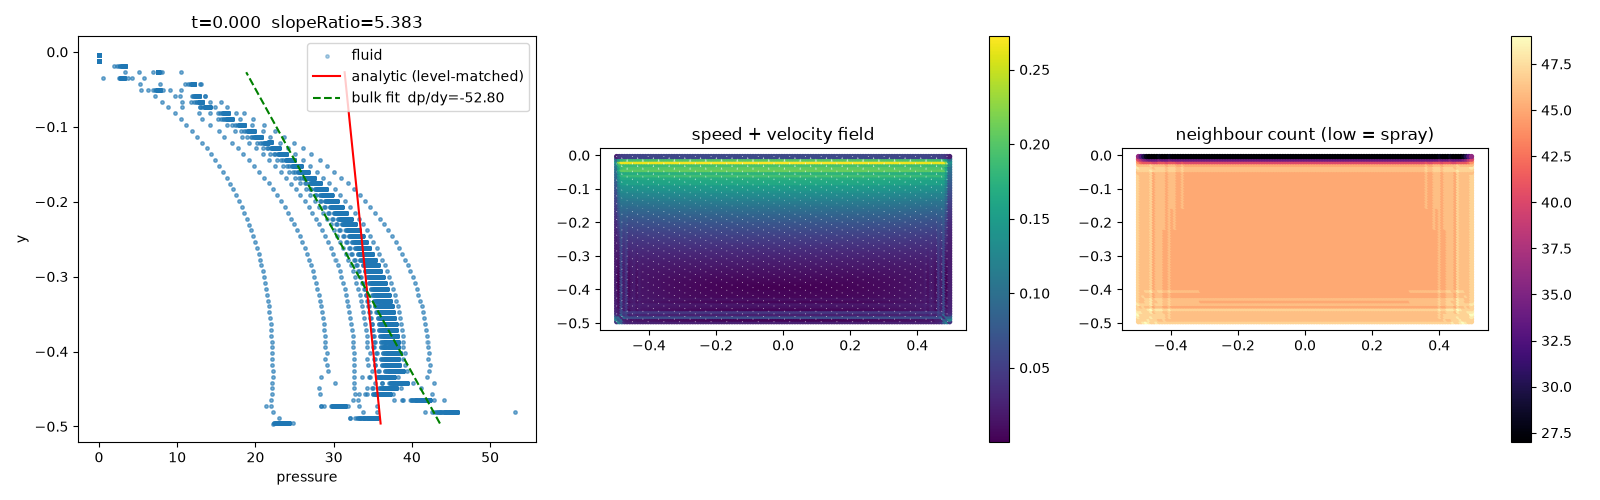

In [ ]:
st = runningState.state
adjF = ref._rebuildAdjacency(st, system, ctx.config)
nb = countNeighbors(st, ctx.config, ctx.schemeConfig, adjF).detach().cpu().numpy()
pos = st.positions.detach().cpu().numpy()
vel = st.velocities.detach().cpu().numpy()
pres = st.pressures.detach().cpu().numpy()
spd = np.linalg.norm(vel, axis=-1)
fl = fluid0
ys = pos[fl, 1]; ysurf = np.quantile(ys, 0.95)

dx = ctx.config.dx
bm, wm = ctx.param('bulkMargin'), ctx.param('wallMargin')
bulk = fl & (pos[:, 1] < ysurf - bm * dx) & (pos[:, 1] > -0.5 * spec.L + wm * dx)
yb, pb = pos[bulk, 1], pres[bulk]
A = np.polyfit(yb, pb, 1)

fig, ax = plt.subplots(1, 3, figsize=(16, 5))

ax[0].scatter(pres[fl], pos[fl, 1], s=6, alpha=0.35, label='fluid')
yy = np.linspace(ys.min(), ysurf, 50)
ax[0].plot(rho0 * g * (ysurf - yy) + np.median(pres[bulk] - rho0 * g * (ysurf - yb)), yy,
           'r-', lw=1.5, label='analytic (level-matched)')
ax[0].plot(np.polyval(A, yy), yy, 'g--', lw=1.5, label=f'bulk fit  dp/dy={A[0]:.2f}')
ax[0].set_xlabel('pressure'); ax[0].set_ylabel('y')
ax[0].set_title(f't={trajectory[-1]["t"]:.3f}  slopeRatio={A[0] / (-rho0 * g):.3f}')
ax[0].legend()

q = ax[1].scatter(pos[fl, 0], pos[fl, 1], c=spd[fl], s=8, cmap='viridis')
st_ = slice(None, None, 6)
ax[1].quiver(pos[fl, 0][st_], pos[fl, 1][st_], vel[fl, 0][st_], vel[fl, 1][st_],
             color='white', scale=30, width=0.003, alpha=0.7)
fig.colorbar(q, ax=ax[1]); ax[1].set_aspect('equal'); ax[1].set_title('speed + velocity field')

s2 = ax[2].scatter(pos[fl, 0], pos[fl, 1], c=nb[fl], s=8, cmap='magma')
fig.colorbar(s2, ax=ax[2]); ax[2].set_aspect('equal')
ax[2].set_title('neighbour count (low = spray)')
fig.tight_layout()

rr = st.densities.detach().cpu().numpy()
spray = fl & (nb < 0.5 * np.median(nb[fl]))
msg = (f'rho over those = [{rr[spray].min():.3f}, {np.median(rr[spray]):.3f}] (min, median)'
       if spray.any() else '(none this frame)')
print(f'neighbour median (fluid): {np.median(nb[fl]):.0f}   '
      f'spray-like (< 0.5x median neighbours): {int(spray.sum())} particles   {msg}')

## Lever recipes

Each is: set it in the **Levers** cell (or the params in the **spec** cell),
re-run **build IC -> instrument -> step loop -> panels**, and read the change
off the trajectory panels. Verdicts are what the plan already found — the
value here is seeing *how* they fail, and having the bench when a new idea
turns up.

| try | expect | plan |
|---|---|---|
| `ref.SKIP_DIVERGENCE_SOLVE = False` | blow-ups on the woken-up surface; `|v|max` -> 1e17, `rho` -> uniform 0.139 | Parts 29/30/33 |
| `nu = 0.005` (or `0.01`) in params | the slosh KE decays instead of plateauing; surface spray thins | Part 32 (free-slip diagnosis) |
| `calibrateRestDensity = True` in params | under `iisph`: gradient builds faster, otherwise ~same. With `SKIP_DIVERGENCE_SOLVE=False`: immediate detonation | Part 33 |
| `ref.DAMPED_WARM_START = True` | `pressureSlopeRatio` collapses toward 0 — the seed starves the accumulating kappa | Part 31/33 |
| `ref.XSPH_BOUNDARY_EPSILON = 0.1` | marginal onset delay; does not decay the slosh; n=1 luck, not a fix | Parts 32/33 |
| `ref.XSPH_FLUID_EPSILON = 0.1` | surface degrades *earlier*; can tip into the soup | Parts 32/33 |
| `jitter = 0.0` in params | perfect lattice = unstable equilibrium; its own setup transient reads as motion | case docstring |
| `nx = 32` in spec | Part 33's resolution — the slosh KE plateaus flatter (~0.12), transient shallower | Parts 33/34 |
| bump `psCfg.maxIterations` (below) | `dfsphReference_step` forces it to >= 100; more CD iters tightens the per-particle residual but not the mean | §1.7 |


In [ ]:
# restore the un-instrumented solve when you're done poking
ref._jacobiSolve = _orig_js
# and reset every lever to the shipped (registered-scheme) defaults
ref.SKIP_DIVERGENCE_SOLVE = False
ref.DAMPED_WARM_START = False
ref.FREE_SURFACE_GAUGE = False
ref.XSPH_FLUID_EPSILON = 0.0
ref.XSPH_BOUNDARY_EPSILON = 0.0
print('restored ref._jacobiSolve and all levers to defaults')